In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')  

from src import queries
from src import plots

query = queries.queries()
query.load_data()

Loaded ../data/dataframes/players.csv into table players
Loaded ../data/dataframes/matches.csv into table matches
Loaded ../data/dataframes/events.csv into table events
Loaded ../data/dataframes/teams.csv into table teams
Loaded ../data/dataframes/positions.csv into table positions
Loaded ../data/dataframes/event_tags.csv into table event_tags
All files loaded into the database!


### Add a `is_goal` column on events for all the shots.

In [2]:
import pandas as pd
import numpy as np

# 1. Load raw tables
events = query.query_this("SELECT events.*, positions.initialX, positions.initialY FROM events JOIN positions ON events.id = positions.id WHERE eventId = 10") # ID 10 is 'Shot'
tags = query.query_this("SELECT * FROM event_tags")
positions = query.query_this("SELECT * FROM positions")

# 2. Create the "Goal" flag
# Filter tags to find only the rows where tag == 101 (Goal)
goal_tags = tags[tags['tag'] == 101]

# 3. Create the 'is_goal' column
# Check if the event's ID exists in our list of 'goal_tags'
# np.where(condition, value_if_true, value_if_false)
events['is_goal'] = np.where(events['id'].isin(goal_tags['event_id']), 1, 0)

print(events[['id', 'playerId', 'is_goal']].head())

          id  playerId  is_goal
0  177959212     25413        1
1  177959247     26150        0
2  177959280     14763        1
3  177959289      7868        0
4  177959429      7868        0


In [3]:
# Now, the events table has all the shots and a `is_goal` value indicating whether it was a goal (1) or not (0).

events

,eventId,subEventName,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,initialX,initialY,is_goal
0,10,Shot,25413,2499719,Shot,1609,1H,94.595788,100.0,177959212,88,41,1
1,10,Shot,26150,2499719,Shot,1631,1H,179.854785,100.0,177959247,85,52,0
2,10,Shot,14763,2499719,Shot,1631,1H,254.745027,100.0,177959280,96,52,1
3,10,Shot,7868,2499719,Shot,1609,1H,425.824035,100.0,177959289,81,33,0
4,10,Shot,7868,2499719,Shot,1609,1H,815.462015,100.0,177959429,75,30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8446,10,Shot,8561,2500098,Shot,1633,2H,1972.969422,100.0,251596053,72,45,0
8447,10,Shot,41174,2500098,Shot,1633,2H,2193.887080,100.0,251596096,86,33,1
8448,10,Shot,7879,2500098,Shot,1623,2H,2377.197700,100.0,251596357,88,62,0
8449,10,Shot,145692,2500098,Shot,1623,2H,2381.481625,100.0,251596359,92,38,0


In [4]:
len(events[events["is_goal"] == 1])

914

### Creating a Player class to store relevant data and methods

In [5]:
class Player:

    def __init__(self, playerId, query):
        self.playerId = playerId
        self.query = query
        self.goals_by_player = events[(events["is_goal"] == 1) & (events["playerId"] == playerId)]
        self.shots_by_player = events[events["playerId"] == playerId]
        
    def get_details(self):
        return self.query.get_player_by_id(self.playerId)

    def get_shot_count(self):
        return len(self.shots_by_player)

    def get_goal_count(self):
        return len(self.goals_by_player)
        
    def get_conversion_rate(self):
        conversion_rate = len(self.goals_by_player)/len(self.shots_by_player)
        return conversion_rate

### Creating a table `player_conversion_df` to store the conversion rate of each player.

In [6]:
player_conversion_df = pd.DataFrame(columns=['playerId', 'name', 'shots', 'goals', 'conversionRate'])

players_id = events["playerId"].unique()

for player_id in players_id:
    myPlayer = Player(player_id, query)
    player_details = myPlayer.get_details()
    player_shots = myPlayer.get_shot_count()
    player_goals = myPlayer.get_goal_count()
    player_conversion = myPlayer.get_conversion_rate()

    new_row_df = pd.DataFrame({'playerId': player_id,
                               'name': player_details["firstName"] + " " + player_details["lastName"],
                               'shots': player_shots,
                               'goals': player_goals,
                               'conversionRate': player_conversion, 
                                })
    player_conversion_df = pd.concat([player_conversion_df, new_row_df], ignore_index=True)

    
#player_conversion_rate = sorted(player_conversion_rate.items(), key=lambda x: x[1], reverse=True)
player_conversion_df.sort_values("goals", ascending=False).head(15)

/var/folders/br/lnqxbh590w5f7n1cs9zmlw000000gn/T/ipykernel_89223/3758092927.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  player_conversion_df = pd.concat([player_conversion_df, new_row_df], ignore_index=True)


,playerId,name,shots,goals,conversionRate
97,120353,Mohamed Salah Ghaly,136,31,0.227941
73,8717,Harry Kane,162,27,0.166667
18,8325,Sergio Leonel Ag\u00fcero del Castillo,86,17,0.197674
158,11066,Raheem Shaquille Sterling,79,17,0.215190
61,7905,Romelu Lukaku Menama,76,16,0.210526
8,12829,Jamie Vardy,60,15,0.250000
149,15808,Roberto Firmino Barbosa de Oliveira,79,14,0.177215
13,340386,Gabriel Fernando de Jesus,53,13,0.245283
0,25413,Alexandre Lacazette,63,12,0.190476
208,14911,Heung-Min Son,70,12,0.171429


In [7]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Shots vs Converstion Rate')

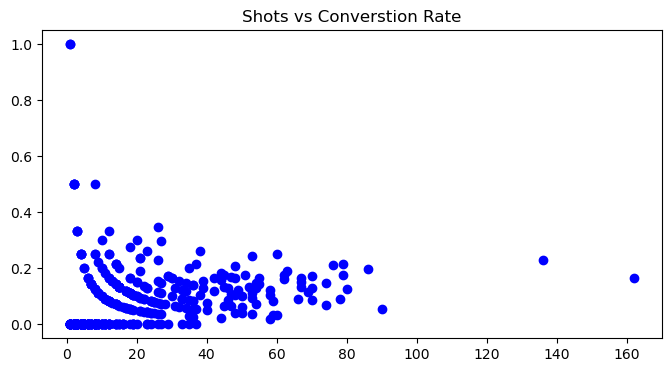

In [8]:
plt.figure(figsize=(8, 4)) # Optional: set figure size
plt.scatter(player_conversion_df["shots"], player_conversion_df["conversionRate"], color='blue') # Pl
plt.title('Shots vs Converstion Rate') # Add title

### Training a LinearRegression model to visualize the correlation between shots and goals

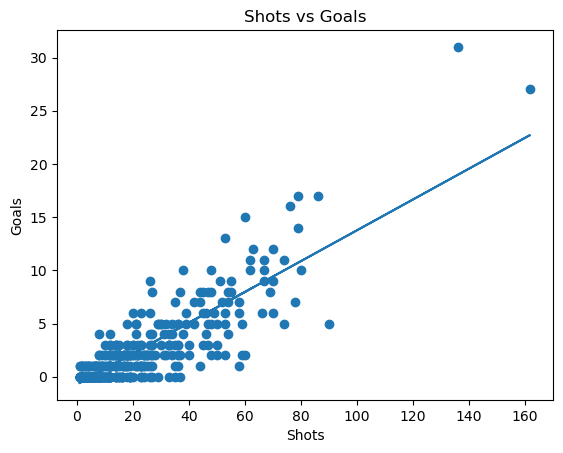

In [9]:
from sklearn.linear_model import LinearRegression

x = player_conversion_df["shots"].values.reshape(-1, 1)
y = player_conversion_df["goals"].values

model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)

plt.scatter(x, y)
plt.plot(x, y_pred)
plt.xlabel("Shots")
plt.ylabel("Goals")
plt.title("Shots vs Goals")
plt.show()


In [10]:
import math

def euclidean(shot_position):
    goal_position = (100, 50)
    return math.dist(shot_position, goal_position)

def calculate_view_angle(row):
    # Coordinates of the goal posts (approximate in 0-100 scale)
    # Standard pitch is 68m wide. Goal is 7.32m. 
    # 7.32m is ~11% of the width. So posts are at 44.5 and 55.5
    post1_y = 55.5
    post2_y = 44.5
    
    dx = 100 - row['initialX']
    if dx == 0: dx = 0.01 # Prevent zero division
    
    # Angle to Post 1
    ang1 = np.arctan((post1_y - row['initialY']) / dx)
    # Angle to Post 2
    ang2 = np.arctan((post2_y - row['initialY']) / dx)
    
    # The view angle is the difference
    view_angle = np.abs(ang1 - ang2)
    return np.degrees(view_angle)

In [11]:
# Calculate the distance and add it to `events`
shot_positions = np.array(list(zip(events["initialX"], events["initialY"])))
shot_distance = np.array([euclidean(x) for x in shot_positions])
events["distance"] = shot_distance

In [12]:
# Calculate angle and add it to `events`
events['angle'] = events.apply(calculate_view_angle, axis=1)

### Training a LogisticRegression Model to calculate the expected goal (xG) for each shot.

In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [14]:
# 1. Load Data
#events = events.drop("xGs", axis=1)
X = np.array(events[["distance", "angle"]])
y = np.array(events[["is_goal"]])

In [15]:
# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# 4. Initialize and Train Model
# random_state ensures reproducibility
model = LogisticRegression(class_weight='balanced', random_state=42) 
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(class_weight='balanced', random_state=42)

In [17]:
# 5. Predict
y_pred = model.predict(X_test)

In [18]:
# Get probabilities for all test samples
goal_probs = model.predict_proba(X_test)

# View the first 5 results
print(goal_probs[:, 1])

[0.61223475 0.53565139 0.78265903 ... 0.36974763 0.39652501 0.08366443]


In [19]:
# 6. Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.69

Confusion Matrix:
[[1048  461]
 [  60  122]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80      1509
           1       0.21      0.67      0.32       182

    accuracy                           0.69      1691
   macro avg       0.58      0.68      0.56      1691
weighted avg       0.87      0.69      0.75      1691



## Calculate xGs for all the shots

In [20]:
xGs = model.predict_proba(X)[:, 1]

In [21]:
events["xGs"] = xGs

In [22]:
# Mean/ Prior Calibration

# 1. Check the Inflation
# Get the global average of REAL goals (e.g., 0.10)
global_conversion_rate = events['is_goal'].mean()

# Get the global average of your PREDICTED xG (e.g., 0.50)
global_predicted_xg = events['xGs'].mean()

print(f"Real Conversion Rate: {global_conversion_rate:.2f}")
print(f"Current Model Avg xG: {global_predicted_xg:.2f}")

# 2. The Correction Factor
# If model says 0.50 but reality is 0.10, we need to divide by 5.
correction_factor = global_conversion_rate / global_predicted_xg

# 3. Apply Correction
# We simply scale the probabilities down
events['xG_Corrected'] = events['xGs'] * correction_factor

# 4. Check the New Results
print("New Model Avg xG:", events['xG_Corrected'].mean())

events = events.drop('xGs', axis=1)
events = events.rename(columns={"xG_Corrected": "xG"})


Real Conversion Rate: 0.11
Current Model Avg xG: 0.42
New Model Avg xG: 0.1081528813158206


In [23]:
events[(events["is_goal"] == 1) & (events["teamId"] == 1625)].sort_values("xG").head(15)

,eventId,subEventName,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,initialX,initialY,is_goal,distance,angle,xG
7743,10,Shot,38021,2500065,Shot,1625,2H,499.438484,100.0,245423267,72,73,1,36.235342,13.501646,0.022980
1756,10,Shot,105339,2499794,Shot,1625,2H,875.061613,100.0,196255567,74,67,1,31.064449,17.012233,0.038818
7999,10,Shot,245364,2500078,Shot,1625,1H,724.868615,100.0,247535050,81,72,1,29.068884,14.387316,0.045924
2258,10,Shot,105339,2499818,Shot,1625,1H,879.706231,100.0,200655849,74,58,1,27.202941,21.947403,0.056523
5712,10,Shot,70083,2499972,Shot,1625,1H,1277.543347,100.0,225711125,78,36,1,26.076810,20.427894,0.061678
855,10,Shot,245364,2499754,Shot,1625,2H,2737.243355,100.0,185704462,77,60,1,25.079872,22.906341,0.067849
1323,10,Shot,8464,2499774,Shot,1625,2H,2586.894650,100.0,190069355,82,33,1,24.758837,18.766135,0.068150
2600,10,Shot,38021,2499834,Shot,1625,2H,192.228458,100.0,206732603,76,43,1,25.000000,23.935668,0.068656
1936,10,Shot,245364,2499802,Shot,1625,2H,1770.350279,100.0,198518773,89,29,1,23.706539,12.819401,0.071911
5938,10,Shot,8325,2499982,Shot,1625,2H,2679.581363,100.0,227275124,77,43,1,24.041631,24.791722,0.074421


In [24]:
query.get_match_by_id(2500065)
query.get_player_by_id(38021)

,weight,firstName,middleName,lastName,currentTeamId,birthDate,height,wyId,foot,shortName,currentNationalTeamId
0,68,Kevin,None,De Bruyne,1625.0,1991-06-28,181,38021,right,K. De Bruyne,5629.0


### Correlation between horizontal distance and xG

In [25]:
corr = events["initialX"].corr(events["xG"])
print(corr)

0.7899771585822024


### Group xGs by players to calculate the toal expected goals by the player.

In [26]:
total_xgs_per_player = (
    events
    .groupby("playerId", as_index=False)["xG"]
    .sum()
    .rename(columns={"xG": "total_xGs"})
)
players = pd.merge(player_conversion_df, total_xgs_per_player, on="playerId")


In [27]:
players

,playerId,name,shots,goals,conversionRate,total_xGs
0,25413,Alexandre Lacazette,63,12,0.190476,8.135946
1,26150,Riyad Mahrez,62,11,0.177419,5.905971
2,14763,Shinji Okazaki,26,6,0.230769,4.186077
3,7868,Alex Oxlade-Chamberlain,47,3,0.063830,3.341019
4,7945,Daniel Nii Tackie Mensah Welbeck,30,5,0.166667,3.809942
...,...,...,...,...,...,...
420,397098,Reiss Nelson,2,0,0.000000,0.213383
421,21333,Yohan Benalouane,2,0,0.000000,0.064891
422,239411,Tyrone Mings,1,0,0.000000,0.044639
423,86325,Jos\u00e9 Ramiro Funes Mori,1,0,0.000000,0.156903


### Calculating the number of goals scored above xG for each player

In [30]:
players["goals above xG"] = np.array(players["goals"]) - np.array(players["total_xGs"])
players[players["shots"] > 10].sort_values("goals above xG", ascending=False).head(15)

,playerId,name,shots,goals,conversionRate,total_xGs,goals above xG
97,120353,Mohamed Salah Ghaly,136,31,0.227941,16.221290,14.77871
73,8717,Harry Kane,162,27,0.166667,19.826270,7.17373
8,12829,Jamie Vardy,60,15,0.250000,7.892695,7.107305
158,11066,Raheem Shaquille Sterling,79,17,0.215190,10.052518,6.947482
18,8325,Sergio Leonel Ag\u00fcero del Castillo,86,17,0.197674,10.898482,6.101518
149,15808,Roberto Firmino Barbosa de Oliveira,79,14,0.177215,8.079053,5.920947
239,245364,Leroy San\u00e9,48,10,0.208333,4.360978,5.639022
13,340386,Gabriel Fernando de Jesus,53,13,0.245283,7.674270,5.32573
208,14911,Heung-Min Son,70,12,0.171429,6.718442,5.281558
394,25867,Pierre-Emerick Aubameyang,26,9,0.346154,3.757074,5.242926


**From the above table, we can see that Salah, Kane and Vardy were the top three overperforming players in terms of the number of goals score in the 2017-18 Premier League season.** 



### Visualizing the Goals vs Shots for Salah and Kane

In [34]:
plot = plots.plots()

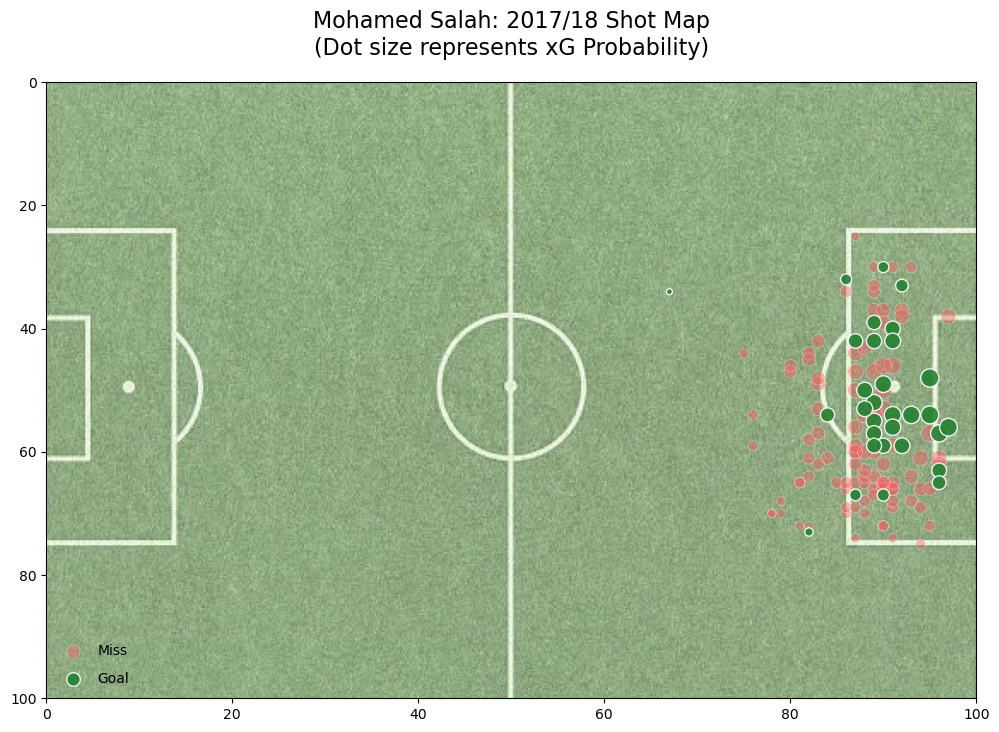

Saved: ../outputs/plots/salah_xg_map.png


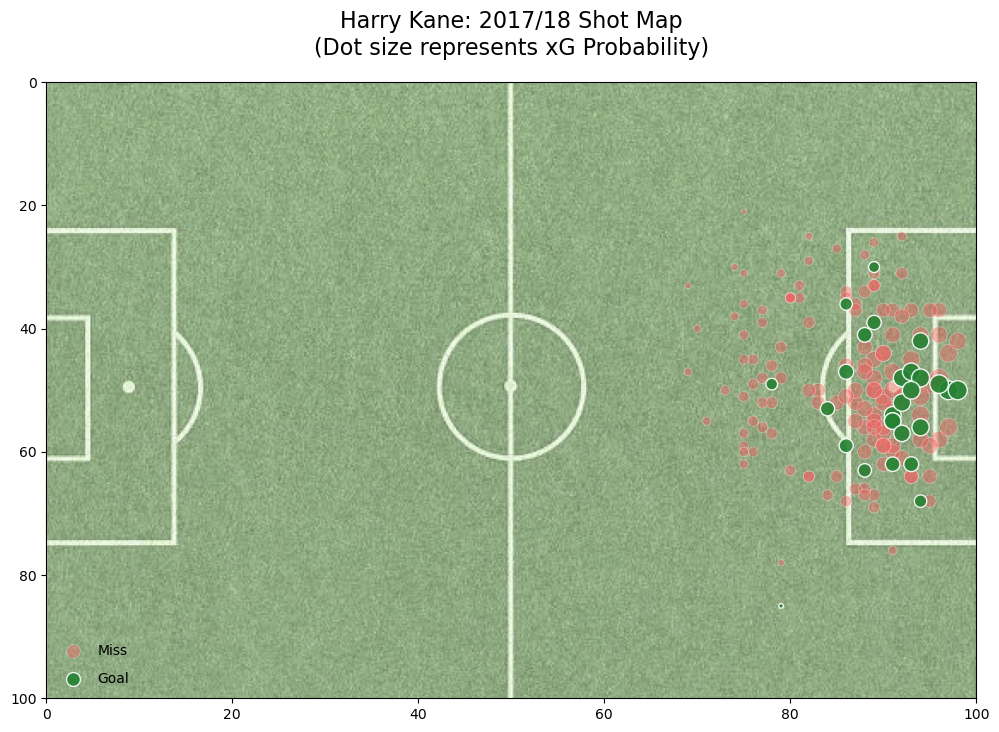

Saved: ../outputs/plots/kane_xg_map.png


In [35]:
import matplotlib.pyplot as plt

def save_xg_map(player_id, player_name, filename):
    # 1. Filter shots for the specific player
    player_shots = events[events["playerId"] == player_id]
    goals = player_shots[player_shots['is_goal'] == 1]
    misses = player_shots[player_shots['is_goal'] == 0]
    
    # 2. Create the plot
    plt.figure(figsize=(12, 8))
    
    # Plot Misses (Red) - size based on xG
    plt.scatter(misses['initialX'], misses['initialY'], 
                s=misses['xG'] * 800, 
                c='#ff5a5f', alpha=0.4, label='Miss', edgecolors='white', linewidth=0.5)
    
    # Plot Goals (Green) - size based on xG
    plt.scatter(goals['initialX'], goals['initialY'], 
                s=goals['xG'] * 800, 
                c='#248232', alpha=0.9, label='Goal', edgecolors='white', linewidth=1)

    plt.title(f"{player_name}: 2017/18 Shot Map\n(Dot size represents xG Probability)", fontsize=16, pad=20)
    plt.legend(loc='lower left', scatterpoints=1, frameon=False, labelspacing=1)
    
    # Overlay the pitch (using your existing plots class logic)
    plot.basic_plot() 
    
    # 3. Save it
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {filename}")

# Generate the two maps for your README
save_xg_map(120353, "Mohamed Salah", "../outputs/plots/salah_xg_map.png")
save_xg_map(8717, "Harry Kane", "../outputs/plots/kane_xg_map.png")

### Visualizing the xG Landscape: Model's Predicted Probability

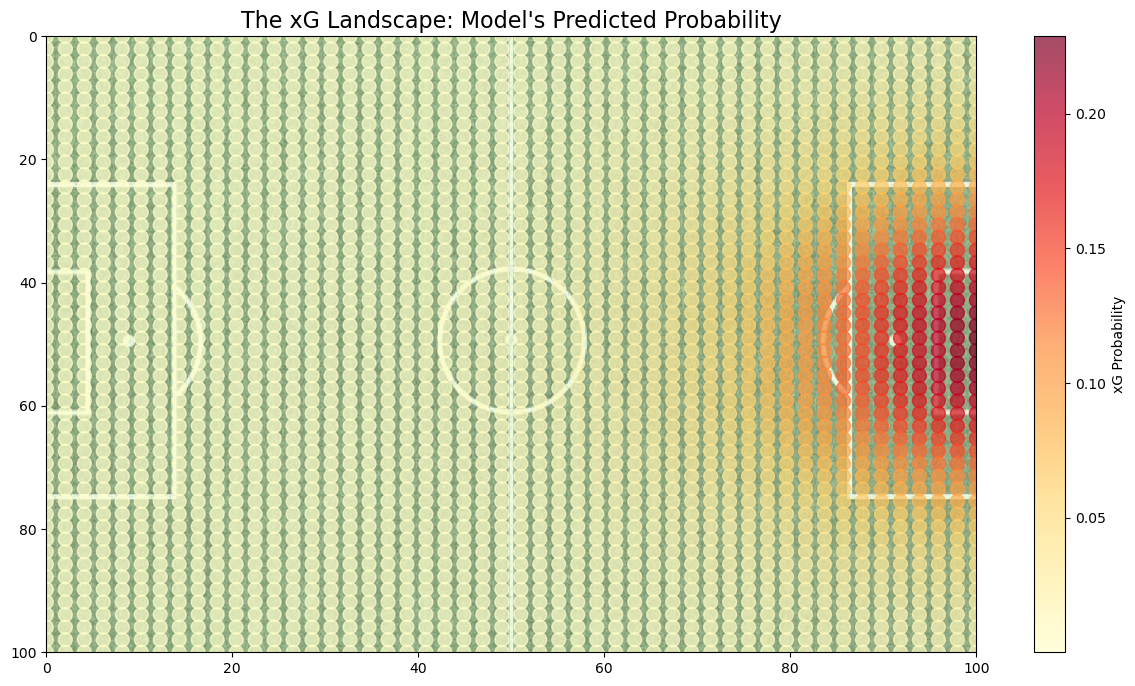

In [39]:

# 1. Create a grid of points for the attacking half (X from 50 to 100)
x_range = np.linspace(0, 100, 50)
y_range = np.linspace(0, 100, 50)
grid_x, grid_y = np.meshgrid(x_range, y_range)

# Flatten for calculation
flat_x = grid_x.flatten()
flat_y = grid_y.flatten()

# 2. FEATURE ENGINEERING: Convert grid X,Y to Distance and Angle
# (This must match exactly how you trained the model)
dist_grid = np.sqrt((100 - flat_x)**2 + (50 - flat_y)**2)

# Calculate angle (handling the dx=0 case)
dx = 100 - flat_x
dx[dx == 0] = 0.1 # avoid division by zero
dy = np.abs(50 - flat_y)
angle_grid = np.degrees(np.arctan(dy / dx))

# 3. PREDICT: Pass the engineered features to the model
# Stack features into the shape (N, 2)
X_grid = np.column_stack((dist_grid, angle_grid))

# Get probabilities for 'Goal' (column 1) and apply your calibration factor
raw_probs = model.predict_proba(X_grid)[:, 1]
calibrated_probs = raw_probs * correction_factor # Using the factor we calculated earlier

# 4. PLOT
plt.figure(figsize=(15, 8))

# We use scatter with a colormap (cmap) to show the "heat"
sc = plt.scatter(flat_x, flat_y, c=calibrated_probs, cmap='YlOrRd', s=100, alpha=0.7)
plt.colorbar(sc, label='xG Probability')

plt.title("The xG Landscape: Model's Predicted Probability", fontsize=16)

# Overlay the pitch background
plot.basic_plot()


#### The above plot shows how the xG is distributed throughout the football pitch. Therefore, xG depends on the distance from the goal and angle.